In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ryanbadai/clothes-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.37G/1.37G [00:10<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1):
['Clothes_Dataset']


In [ ]:
import os

# Explore the structure inside 'Clothes_Dataset'
clothes_path = os.path.join(path, 'Clothes_Dataset')
if os.path.exists(clothes_path):
    print(f"Subdirectories in Clothes_Dataset: {os.listdir(clothes_path)}")
else:
    print(f"Directory {clothes_path} does not exist. Please check the file structure.")

Subdirectories in Clothes_Dataset: ['Celana_Panjang', 'Gaun', 'Jaket_Denim', 'Celana_Pendek', 'Rok', 'Blazer', 'Jaket_Olahraga', 'Kaos', 'Polo', 'Hoodie', 'Jeans', 'Sweter', 'Mantel', 'Kemeja', 'Jaket']


Found 7500 images. Displaying 6 sample images:


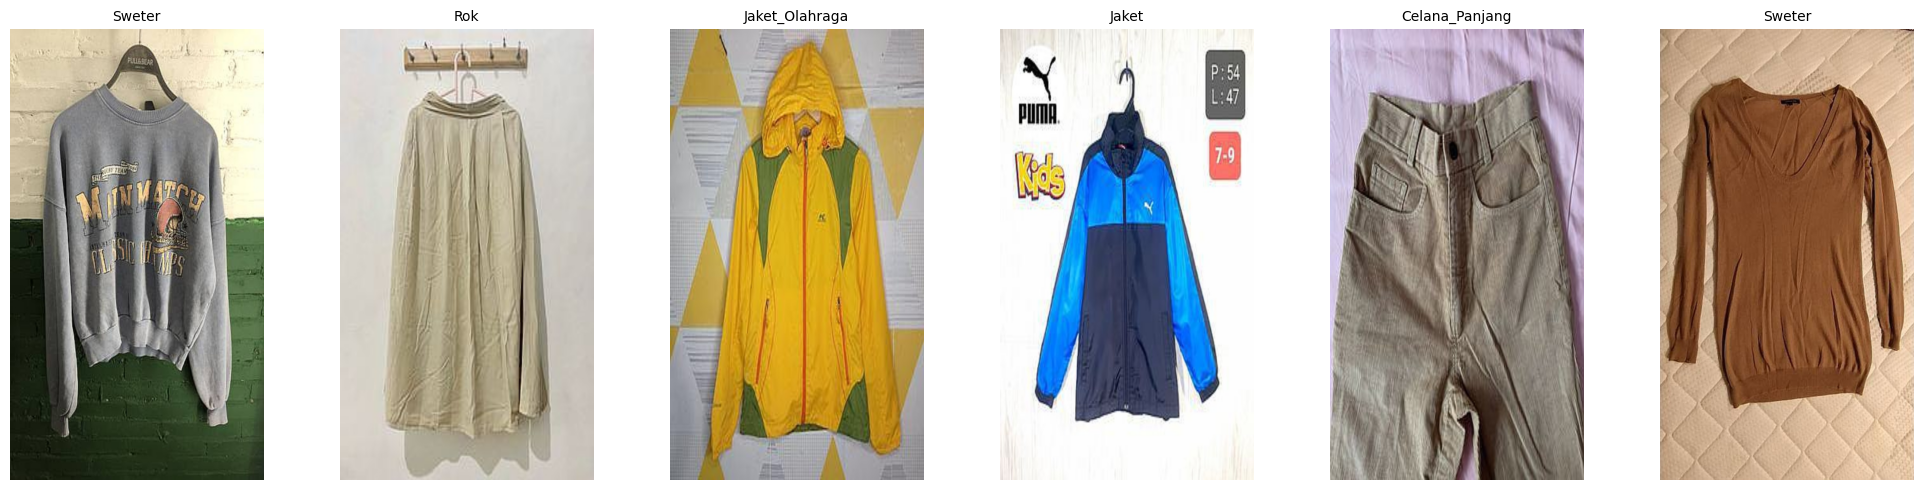

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the actual path of the clothes dataset
clothes_path = os.path.join(path, 'Clothes_Dataset')
display_sample_images(clothes_path)

In [ ]:
import os

# Define paths for the clothes dataset
input_folder = os.path.join(path, 'Clothes_Dataset')
output_folder = '/content/clothes_dataset_split'

if os.path.exists(input_folder):
    print(f"Preparing to split clothes data from: {input_folder}")
else:
    print(f"Error: {input_folder} not found.")

Preparing to split clothes data from: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1/Clothes_Dataset


In [ ]:
!pip install split-folders

In [ ]:
import os
try:
    import splitfolders
except ImportError:
    !pip install split-folders
    import splitfolders

# Split the clothes dataset: train=0.8, val(test)=0.2
# seed=42 for reproducibility
if os.path.exists(input_folder):
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Clothes dataset split successfully into: {output_folder}")

Copying files: 7500 files [00:07, 1023.03 files/s]

Clothes dataset split successfully into: /content/clothes_dataset_split


In [ ]:
# Check the directory structure of the split clothes dataset
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 1: # Showing top level folders (train/val)
        print(f"{indent}{os.path.basename(root)}/")

clothes_dataset_split/
    train/
    val/


In [ ]:
import os

def count_files(directory):
    if not os.path.exists(directory):
        return 0
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"Clothes Dataset Statistics:")
if total > 0:
    print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%) -- Target: 80%")
    print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%) -- Target: 20%")
    print(f"- Total images: {total}")
else:
    print("No images found. Please ensure the split command in the previous cell executed successfully.")

Clothes Dataset Statistics:
- Train Set: 6000 images (80.0%) -- Target: 80%
- Test Set (val): 1500 images (20.0%) -- Target: 20%
- Total images: 7500


## GPU Check and Model Building

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", gpus)
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. Training will run on CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


## Prepare Data for Model Training

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions and batch size
IMG_HEIGHT = 224 # VGG16 input size
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for Validation Set (no augmentation needed)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # For multi-class classification
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 6000 images belonging to 15 classes.
Found 1500 images belonging to 15 classes.


## Build and Compile the VGG16 Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Load the VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of VGG16
x = base_model.output
x = Flatten()(x) # Flatten the output of the VGG16 base
x = Dense(256, activation='relu')(x)
num_classes = len(train_generator.class_indices) # Get number of classes from generator
predictions = Dense(num_classes, activation='softmax')(x) # Output layer for classification

# Combine base model and new layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,141,327 (80.65 MB)

 Trainable params: 6,426,639 (24.52 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train the VGG16 Model

In [ ]:
# Define the number of epochs
EPOCHS = 10

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 147s 710ms/step - accuracy: 0.3525 - loss: 2.0481 - val_accuracy: 0.5625 - val_loss: 1.3447
Epoch 2/10
  1/187 ━━━━━━━━━━━━━━━━━━━━ 34s 186ms/step - accuracy: 0.3750 - loss: 1.8430

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.3750 - loss: 1.8430 - val_accuracy: 0.5632 - val_loss: 1.3449
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 120s 642ms/step - accuracy: 0.5292 - loss: 1.4935 - val_accuracy: 0.6121 - val_loss: 1.2023
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.6875 - loss: 1.1152 - val_accuracy: 0.6094 - val_loss: 1.1988
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 122s 650ms/step - accuracy: 0.5662 - loss: 1.3390 - val_accuracy: 0.6556 - val_loss: 1.0718
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.5938 - loss: 1.5001 - val_accuracy: 0.6427 - val_loss: 1.0971
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 121s 646ms/step - accuracy: 0.6079 - loss: 1.2347 - val_accuracy: 0.6569 - val_loss: 1.0555
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.4062 - loss: 1.6958 - val_accuracy: 0.6596 - val_loss: 1.0605
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 122s 653ms/step - accuracy: 0.6397 - loss: 1.1282 - v

## Training Results Summary

In [ ]:
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // BATCH_SIZE)

print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.6780 - loss: 0.9940

Final Validation Loss: 0.9940
Final Validation Accuracy: 67.80%


## Visualize Training History

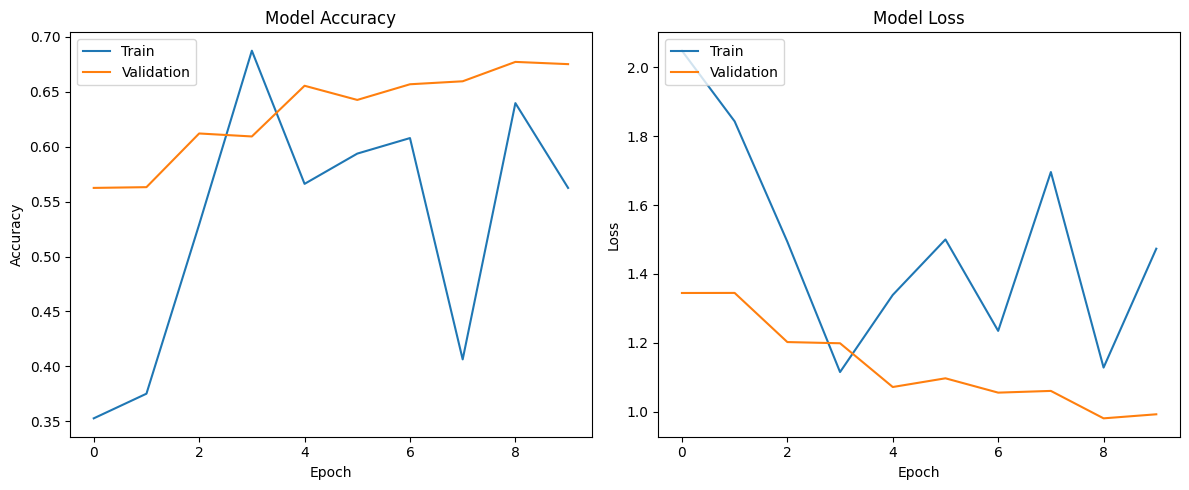

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()